# Step 0 — QAOA Baseline: Coloring a Map with a Quantum Algorithm

**CUDA-Q QAOA GPU-Optimization Learning Path · notebook 0 as a starting point**

| Step | What it teaches | Simulator |
|---|---|---|
| **0 (this)** | the full QAOA workflow, from theory to a colored map | `qpp-cpu` (CPU) vs `nvidia` (GPU) |
| 1 | comparing optimizers + tuning the GPU with environment variables | `nvidia` |
| 2 | scaling up with tensor networks: 9 zones, 36 qubits | `tensornet` |
| 3 | making tensor-network runs faster (contraction path reuse) | `tensornet` |
| 4 | trading accuracy for speedup using MPS | `tensornet-mps` |

In this notebook you will:

1. turn a map-coloring puzzle into a single energy formula (a **QUBO**),
2. rewrite that formula in the language of qubits (a **spin Hamiltonian**),
3. build a small quantum circuit (**QAOA**) with two tunable knobs, γ and β,
4. let a classical optimizer turn those knobs to lower the average energy —
   first on a CPU simulator, then on a GPU simulator,
5. **sample** the optimized circuit and check that a sampled answer really is a
   correctly colored map.

Our example puzzle: color the four planning regions of Taiwan (North, Central, South, East) with
four colors so that neighboring regions never share a color. It is deliberately tiny — 16 qubits —
so everything is easy to inspect. Nothing in the code is special to Taiwan: swap in any other
nodes and edges and it all still works.

## 1 · The theory, from first principles

### A map becomes dots and lines
Shrink each region to a dot (a *node*), and connect two dots with a line (an *edge*) whenever the
regions share a border. Map coloring then asks: **give every node one of $K$ colors so that no
edge connects two nodes of the same color.** Our map has 4 nodes and 5 edges (North–South is the
missing pair — they never touch), and $K = 4$ colors.

Why is this interesting? Because the number of possible colorings explodes as maps grow, while
*checking* one proposed coloring stays easy. Problems with that flavor — huge search space, cheap
checking — are everywhere (timetables, delivery routes, investment choices), and they are exactly
where optimization algorithms earn their keep.

### Writing the rules as one formula (the QUBO)
Give every node $v$ and color $c$ its own binary variable that is either 0 or 1:

$$x_{v,c} = 1 \quad\text{means}\quad \text{"node } v \text{ has color } c\text{"}.$$

With 4 nodes and 4 colors that is $4 \times 4 = 16$ variables. Now we turn both rules into
penalties — terms that are **zero when the rule is obeyed and positive when it is broken**:

- **"Every node gets exactly one color."** Look at one node's four variables and form
  $(x_{v,0} + x_{v,1} + x_{v,2} + x_{v,3} - 1)^2$. If exactly one of them is 1, the bracket is
  $1 - 1 = 0$ — no penalty. If the node has no color, or two colors, the bracket becomes $-1$ or
  $+1$ or more, and squaring makes the penalty positive.
- **"Neighbors differ."** For each edge $(u,v)$ and each color $c$, the product
  $x_{u,c}\, x_{v,c}$ is 1 only when *both* neighbors chose color $c$ — exactly the situation we
  want to punish.

Add everything up with weights $A$ and $B$:

$$H \;=\; A \sum_{v}\Big(\sum_{c} x_{v,c}-1\Big)^{2}
\;+\; B \sum_{(u,v)\in E}\sum_{c} x_{u,c}\,x_{v,c}$$

$H$ is called the **energy**. It is never negative, and $H = 0$ happens *exactly* for valid
colorings. So "solve the puzzle" becomes "find an assignment with energy 0".

**Choosing the weights.** We use $B = 1$ and $A = 4$. The reason: breaking the one-color rule at
some node saves at most one clash per neighbor — at most 3 here, since no node has more than 3
neighbors — but costs at least $A = 4$. Cheating never pays, so the lowest-energy states keep one
color per node. (General recipe: $A \ge \Delta B + 1$, where $\Delta$ is the largest number of
neighbors any node has.)

A formula of this shape — binary variables, at most products of two of them — is called a **QUBO**
(*Quadratic Unconstrained Binary Optimization*). Countless real problems can be written as QUBOs,
and everything below works for *any* QUBO, not just map coloring.

For our small instance we can even count the answers: of the $2^{16} = 65{,}536$ possible bit
patterns, **exactly 48 are valid colorings**. Random guessing would succeed about 0.07% of the
time — that is the number our quantum algorithm has to beat.

### From bits to qubits (the spin Hamiltonian)
A qubit, when measured, gives 0 or 1 — like a bit. The quantum operator $Z$ reports that outcome
as $+1$ (for 0) or $-1$ (for 1). To translate our formula to qubits, substitute

$$x = \frac{1 - Z}{2} \qquad\Big(\text{check: } Z=+1 \Rightarrow x=0,\quad Z=-1 \Rightarrow x=1\Big)$$

and multiply everything out. The result has three kinds of pieces: plain numbers, single-$Z$
terms, and $Z \cdot Z$ terms:

$$H \;=\; \mathrm{offset} \;+\; \sum_p h_p Z_p \;+\; \sum_{p<q} J_{pq}\, Z_p Z_q .$$

The plain-number part (the **offset** — it works out to 37 here) is carried along on paper and
added back to every energy we report, so that a valid coloring still reads exactly 0. A nice
bonus fact: 37 is also the *average* energy over all 65,536 bit patterns, which is exactly the
energy of the "know-nothing" state that gives every pattern an equal chance — we will see that
number appear in the notebook as a quick sign that everything is wired correctly.

### The QAOA circuit: two knobs and a loop
The **Quantum Approximate Optimization Algorithm** builds a circuit from three ingredients:

1. **Start in superposition.** A Hadamard gate (`h`) on every qubit prepares the state that holds
   *all* 65,536 bit patterns at once, each with equal weight.
2. **Cost layer (knob γ).** Rotate each pattern's quantum phase in proportion to its energy.
   Because $H$ contains only $Z$ and $ZZ$ pieces, this layer needs nothing fancier than `rz`
   rotations and pairs of CNOTs (`cx`) — one- and two-qubit gates only.
3. **Mixer layer (knob β).** An `rx` rotation on every qubit lets the amplitudes flow between
   patterns, so the phase differences from step 2 turn into *probability* differences.

Repeat cost + mixer $p$ times ($p = 1$ for us: two knobs total). Then the loop:
`cudaq.observe` computes the **average energy** $\langle H\rangle$ of the circuit's output — on a
simulator this is exact, with no randomness — and a classical optimizer adjusts $(\gamma, \beta)$
to push that average down. When the optimizer finishes, `cudaq.sample` measures the circuit many
times; low-energy bitstrings — valid colorings — now show up far more often than by luck.

One honesty rule for the whole series: **only bitstrings actually produced by sampling count as
answers.** No fixing solutions up by classical post-processing.

In [1]:
# Cell 1 — set up the problem: 4 regions x 4 colors -> a 16-qubit QUBO.
import sys, time
import matplotlib.pyplot as plt
import helpers as hp
import cudaq

cudaq.set_random_seed(1234)          # fixed seed, so sampling gives the same result every run
cudaq.set_target("qpp-cpu")          # start on the exact CPU simulator
print(f"CUDA-Q {cudaq.__version__.split()[2]}   Python {sys.version.split()[0]}")

taiwan = hp.load_map()               # polygons + region/zone tags + adjacency lists
NODES = hp.REGION_ORDER              # ["North", "Central", "South", "East"]
EDGES = taiwan["region_edges"]       # the 5 neighboring pairs (North-South do not touch)
K = 4                                # number of colors
A, B = 4.0, 1.0                      # penalty weights (A >= 3*B + 1, see the theory above)
N = len(NODES) * K                   # 16 qubits, one per (region, color) pair

coeffs, qubo_offset = hp.build_qubo(NODES, EDGES, K, A, B)
H, terms, offset = hp.qubo_to_spin(coeffs, qubo_offset)
print(f"{len(NODES)} regions x {K} colors = {N} qubits")
print(f"spin Hamiltonian: {len(terms['z'])} Z terms + {len(terms['zz'])} ZZ terms, "
      f"constant offset {offset}")

CUDA-Q amd64-cu13-0.15.0   Python 3.12.3
4 regions x 4 colors = 16 qubits
spin Hamiltonian: 16 Z terms + 44 ZZ terms, constant offset 37.0


## 2 · The QAOA circuit in CUDA-Q

The kernel below is the whole circuit. Reading guide:

| line | what it does |
|---|---|
| `h(q)` | puts every qubit in superposition — the all-patterns-at-once start |
| `rz(2·γ·w, ...)` | cost layer, single-$Z$ term with weight $w$ |
| `cx · rz(2·γ·w) · cx` | cost layer, $ZZ$ term — two CNOTs wrap an `rz` on the second qubit |
| `rx(2·β, ...)` | mixer layer on every qubit |

Only one- and two-qubit gates appear — a rule we keep for the whole series. CUDA-Q kernels accept numbers and lists
of numbers as arguments, so the Hamiltonian is handed over as flat lists.

The quick print at the end evaluates the energy with both knobs at zero. In that case the circuit
does nothing — the state is still the equal superposition — so the printed value should be the
all-patterns average from the theory section: the offset, 37.

In [2]:
# Cell 2 — the p = 1 QAOA circuit (only 1- and 2-qubit gates).
@cudaq.kernel
def qaoa_kernel(n: int, zq: list[int], zc: list[float], zz1: list[int],
                zz2: list[int], zzc: list[float], gammas: list[float], betas: list[float]):
    q = cudaq.qvector(n)
    h(q)                                              # start in superposition
    for layer in range(len(gammas)):
        for i in range(len(zq)):                      # cost layer: Z terms
            rz(2.0 * gammas[layer] * zc[i], q[zq[i]])
        for i in range(len(zz1)):                     # cost layer: ZZ terms
            x.ctrl(q[zz1[i]], q[zz2[i]])
            rz(2.0 * gammas[layer] * zzc[i], q[zz2[i]])
            x.ctrl(q[zz1[i]], q[zz2[i]])
        for i in range(n):                            # mixer layer
            rx(2.0 * betas[layer], q[i])

zq, zc, zz1, zz2, zzc = hp.terms_to_lists(terms)

def energy(params):
    # average energy <H> + offset at the angles gamma = params[0], beta = params[1]
    gamma = params[0]
    beta = params[1]
    return cudaq.observe(qaoa_kernel, H, N, zq, zc, zz1, zz2, zzc,
                         [gamma], [beta]).expectation() + offset

print(f"energy at gamma = 0, beta = 0:  {energy([0.0, 0.0]):.3f}   (expected: the offset, 37)")

energy at gamma = 0, beta = 0:  37.000   (expected: the offset, 37)


## 3 · Optimize on the CPU, then on the GPU

Now the classical loop: COBYLA (a standard optimizer that needs no derivatives) turns the two
knobs, starting from $(\gamma, \beta) = (0.1,\, 0.1)$, with a budget of **50 energy evaluations**
(`max_iterations = 50`). This is the plain baseline of the series — intentionally simple and
functional; the next notebooks improve on it, one clearly named change at a time.

We run the *identical* optimization twice: first on the exact CPU simulator (`qpp-cpu`, which
computes in fp64 — double precision), then we switch the target to the GPU simulator (`nvidia`,
fp32 — single precision) and run it again with the same kernel. Both backends compute the same
mathematics, so the two results land close together — but the tiny arithmetic differences of
fp32 vs fp64 can nudge the optimizer onto a slightly different path, so the final numbers may
differ a little (here by well under 1%). The elapsed times, on the other hand, can differ a lot;
that comparison is the point of the next section.

In [3]:
# Cell 3 — the same optimization on the CPU first, then on the GPU.
num_iterations = 50    # the optimizer may call energy() at most this many times
START = [0.1, 0.1]     # starting values for (gamma, beta)

step = [0]
def timed_energy(params):                       # energy(), timing and printing each call
    t0 = time.perf_counter()
    value = energy(params)
    step[0] += 1
    print(f"  iteration {step[0]:2d}: {(time.perf_counter() - t0) * 1e3:8.2f} ms   energy {value:.4f}")
    return value

def optimize_once(fn):
    # run COBYLA from the same start with the same budget, and time it
    optimizer = cudaq.optimizers.COBYLA()
    optimizer.max_iterations = num_iterations
    optimizer.initial_parameters = START
    t0 = time.perf_counter()
    best_energy, best_angles = optimizer.optimize(dimensions=2, function=fn)
    return best_energy, best_angles, time.perf_counter() - t0

cudaq.set_target("qpp-cpu")                     # exact CPU simulator (fp64)
cpu_best, cpu_angles, cpu_opt_seconds = optimize_once(energy)
print(f"CPU (qpp-cpu) : best energy {cpu_best:.6f} at gamma = {cpu_angles[0]:.4f}, "
      f"beta = {cpu_angles[1]:.4f}   ({cpu_opt_seconds:.3f} s)")

cudaq.set_target("nvidia", option="fp32")       # single-GPU simulator (fp32)
print("per-iteration GPU time:")
gpu_best, gpu_angles, gpu_opt_seconds = optimize_once(timed_energy)   # time each GPU iteration
print(f"GPU (nvidia)  : best energy {gpu_best:.6f} at gamma = {gpu_angles[0]:.4f}, "
      f"beta = {gpu_angles[1]:.4f}   ({gpu_opt_seconds:.3f} s)")

CPU (qpp-cpu) : best energy 17.229950 at gamma = 1.5399, beta = 2.2946   (68.833 s)
per-iteration GPU time:
  iteration  1:    31.10 ms   energy 51.0405
  iteration  2:     2.50 ms   energy 35.8708
  iteration  3:     2.00 ms   energy 33.3275
  iteration  4:     1.90 ms   energy 37.9300
  iteration  5:     1.84 ms   energy 67.3821
  iteration  6:     2.13 ms   energy 37.5276
  iteration  7:     5.27 ms   energy 49.5321
  iteration  8:     1.82 ms   energy 25.2816
  iteration  9:     1.71 ms   energy 18.3939
  iteration 10:     1.75 ms   energy 52.2472
  iteration 11:     1.70 ms   energy 34.8739
  iteration 12:     1.84 ms   energy 33.3551
  iteration 13:     1.66 ms   energy 18.0484
  iteration 14:     1.81 ms   energy 19.1343
  iteration 15:     5.38 ms   energy 19.5748
  iteration 16:     1.75 ms   energy 18.4789
  iteration 17:     5.75 ms   energy 18.0913
  iteration 18:     1.83 ms   energy 17.9424
  iteration 19:     1.78 ms   energy 17.6952
  iteration 20:     1.85 ms   energy 

## 4 · Sample the result and time the two simulators

The optimizer only ever looked at *average* energies. To get actual colorings we now **sample**
the optimized circuit 100,000 times on the GPU — always *after* optimization, never during — and
decode each measured bitstring back into colors.

This is also where the notebook performs its one and only check: **the best sampled bitstring
must be a valid coloring** (every region exactly one color, neighbors different).

Then the timing comparison. Both simulators evaluate the energy at the *same angles* with the
same Hamiltonian; a warm-up call comes first so one-time compilation is not mistaken for
computing speed.

In [4]:
# Cell 4 — sample 100,000 shots (GPU), decode, check, and time both simulators.
shots = cudaq.sample(qaoa_kernel, N, zq, zc, zz1, zz2, zzc,
                     [gpu_angles[0]], [gpu_angles[1]], shots_count=100000)
counts = {}
for bitstring, times_seen in shots.items():
    counts[bitstring] = times_seen

result = hp.summarize_samples(counts, NODES, K, EDGES, coeffs, qubo_offset)

# THE check of this notebook: the sampled answer really is a valid coloring.
assert result["best"] is not None and hp.is_valid(result["best"], NODES, K, EDGES)
print("check passed: the best sampled bitstring is a valid coloring (energy 0)")

def one_evaluation():
    energy(gpu_angles)                  # the same angles for both timings

t_gpu = hp.time_it(one_evaluation)      # we are still on the nvidia target here
cudaq.set_target("qpp-cpu")
t_cpu = hp.time_it(one_evaluation)
speedup = t_cpu / t_gpu
print(f"\none energy evaluation:  CPU {t_cpu:.4f} s   GPU {t_gpu:.4f} s"
      f"   ->  speedup {speedup:.0f}x")

valid colorings among raw samples: 36 / 100,000 shots = 0.0360%  (25 distinct bitstrings)
best valid coloring: '0100001001000001' (sampled 4 times, energy 0.0)
   North=1, Central=2, South=1, East=3
check passed: the best sampled bitstring is a valid coloring (energy 0)

one energy evaluation:  CPU 1.8039 s   GPU 0.0032 s   ->  speedup 563x


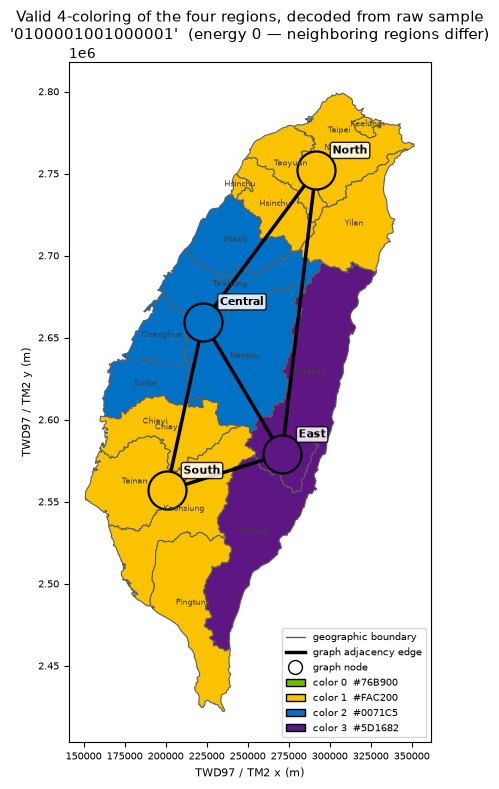

look along each black edge: the two regions it connects always have different colors
(North and South share a color here — allowed, because they are not neighbors)


In [5]:
# Cell 5 — the decoded coloring on the map.
best_coloring = result["assignment"]             # e.g. {"North": 1, "Central": 0, ...}
unit_colors = {}
for name, county in taiwan["counties"].items():  # paint every county with its region's color
    unit_colors[name] = hp.PALETTE[best_coloring[county["region"]]]
node_colors = {}
for region in hp.REGION_ORDER:
    node_colors[region] = hp.PALETTE[best_coloring[region]]

fig, ax = hp.plot_map(taiwan, unit_colors=unit_colors,
                      node_pos=hp.group_positions(taiwan, "region"), edges=EDGES,
                      node_colors=node_colors, unit_labels=True, color_legend=True,
                      title="Valid 4-coloring of the four regions, decoded from raw sample\n"
                            f"'{result['best']}'  (energy 0 — neighboring regions differ)")
plt.show()
print("look along each black edge: the two regions it connects always have different colors")
print("(North and South share a color here — allowed, because they are not neighbors)")

In [6]:
# Cell 6 — summary.
print("SUMMARY")
print("-" * 66)
print(f"problem            : {len(NODES)} regions x {K} colors = {N} qubits (A={A}, B={B})")
print(f"best energy        : CPU {cpu_best:.6f} | GPU {gpu_best:.6f}")
print(f"best angles (GPU)  : gamma = {gpu_angles[0]:.6f}, beta = {gpu_angles[1]:.6f}")
print(f"valid-sample rate  : {result['valid_rate']:.4%} of 100,000 shots")
print(f"best raw coloring  : '{result['best']}' with energy {result['best_energy']:.1f}")
print(f"one evaluation     : CPU {t_cpu:.4f} s | GPU {t_gpu:.4f} s | speedup {speedup:.0f}x")
print(f"optimization time  : CPU {cpu_opt_seconds:.1f} s | GPU {gpu_opt_seconds:.2f} s")
print("-" * 66)

SUMMARY
------------------------------------------------------------------
problem            : 4 regions x 4 colors = 16 qubits (A=4.0, B=1.0)
best energy        : CPU 17.229950 | GPU 17.305686
best angles (GPU)  : gamma = 1.529562, beta = 2.266552
valid-sample rate  : 0.0360% of 100,000 shots
best raw coloring  : '0100001001000001' with energy 0.0
one evaluation     : CPU 1.8039 s | GPU 0.0032 s | speedup 563x
optimization time  : CPU 68.8 s | GPU 0.14 s
------------------------------------------------------------------


## 5 · What you should take away

1. **The workflow**: rules → penalties → QUBO → spin Hamiltonian → QAOA circuit → optimize the
   knobs with `cudaq.observe` → `cudaq.sample` at the end → decode and check. Each stage is
   simple; together they turn a puzzle into something a quantum computer (or its simulator) can
   work on — and the final answer can always be verified by just looking at the colored map.
2. **Penalty design matters**: the weights ($A \ge \Delta B + 1$) guarantee that breaking a rule
   never pays, and tracking the constant offset keeps "energy 0" meaning "puzzle solved".
3. **Significant speedup**: Even for this 16-qubit example, the GPU delivers a speedup of two to three orders of magnitude over the CPU. At larger qubit counts, particularly beyond 30 qubits, the speedup can reach four orders of magnitude for some state-vector simulations.